## Plot Abil Output

In [1]:
import cartopy.crs as ccrs
import cartopy as cart
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import xarray as xr
import os
import sys
from yaml import load, Loader
from matplotlib import cm
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker

In [2]:
with open('regressor.yml', 'r') as f:
    model_config = load(f, Loader=Loader)

run_name = 'pp_na/'
file = '2026-04-28_mean'
ds_mean = xr.open_dataset(model_config['local_root'] + model_config['path_out'] + run_name + 'posts/' + file + ".nc")
varname='Primary_Production'

### Create of map of surface pimary production in April

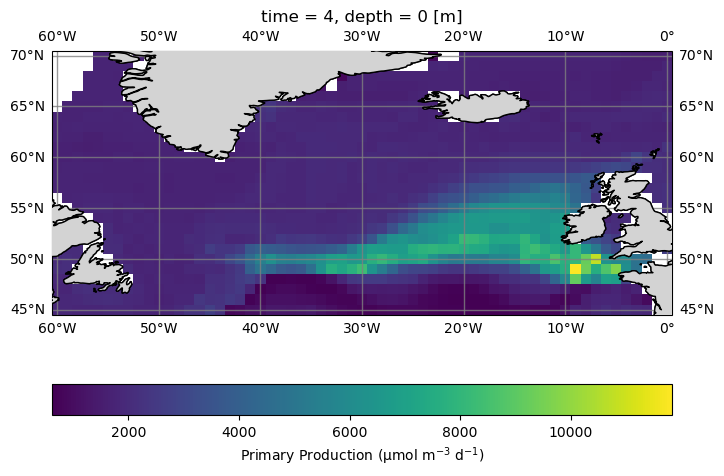

In [3]:
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and land fill color
ax.coastlines()
ax.add_feature(cart.feature.LAND, 
               linewidth = 1, 
               zorder=3, 
               edgecolor='k', 
               facecolor="lightgray")

ax.gridlines(draw_labels=True, 
             linewidth=1,
             color='gray',
             alpha=0.8,
             linestyle='-',
             zorder=1
)
p = ds_mean[varname].sel(
    depth=0, 
    time=4
    ).plot(
        x='lon',
        y='lat',
        transform=ccrs.PlateCarree(),
        add_colorbar=False,)


cbar = plt.colorbar(p, 
                    location='bottom', 
                    label="Primary Production (µmol m$^{-3}$ d$^{-1}$)")

### Create map of depth integrated annual production

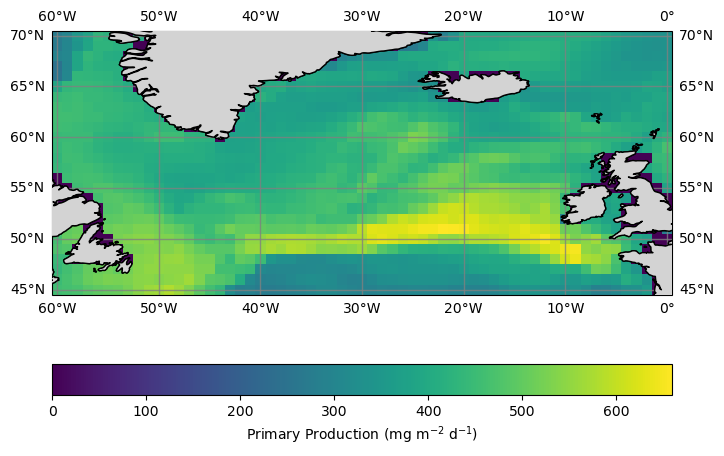

In [4]:
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and land fill color
ax.coastlines()
ax.add_feature(cart.feature.LAND, 
               linewidth = 1, 
               zorder=3, 
               edgecolor='k', 
               facecolor="lightgray")

ax.gridlines(draw_labels=True, 
             linewidth=1,
             color='gray',
             alpha=0.8,
             linestyle='-',
             zorder=1
)

conversion_factor = 12.01e-3 # µmol to mg of C (C atomic weight)
depth_width = 5
depth_integrated_pp = ds_mean[varname].sum(dim=["depth"]).mean(dim="time") * depth_width * conversion_factor

p = depth_integrated_pp.plot(
        x='lon',
        y='lat',
        transform=ccrs.PlateCarree(),
        add_colorbar=False,)


cbar = plt.colorbar(p, 
                    location='bottom', 
                    label="Primary Production (mg m$^{-2}$ d$^{-1}$)")

### Plot timeseries of production

In [5]:
# Load confidence intervals
file_LL = '2026-04-28_ci95_LL'
ds_LL = xr.open_dataset(model_config['local_root'] + model_config['path_out'] + run_name + 'posts/' + file_LL + ".nc")
file_UL = '2026-04-28_ci95_UL'
ds_UL = xr.open_dataset(model_config['local_root'] + model_config['path_out'] + run_name + 'posts/' + file_UL + ".nc")

Text(0.5, 0, 'Time (months)')

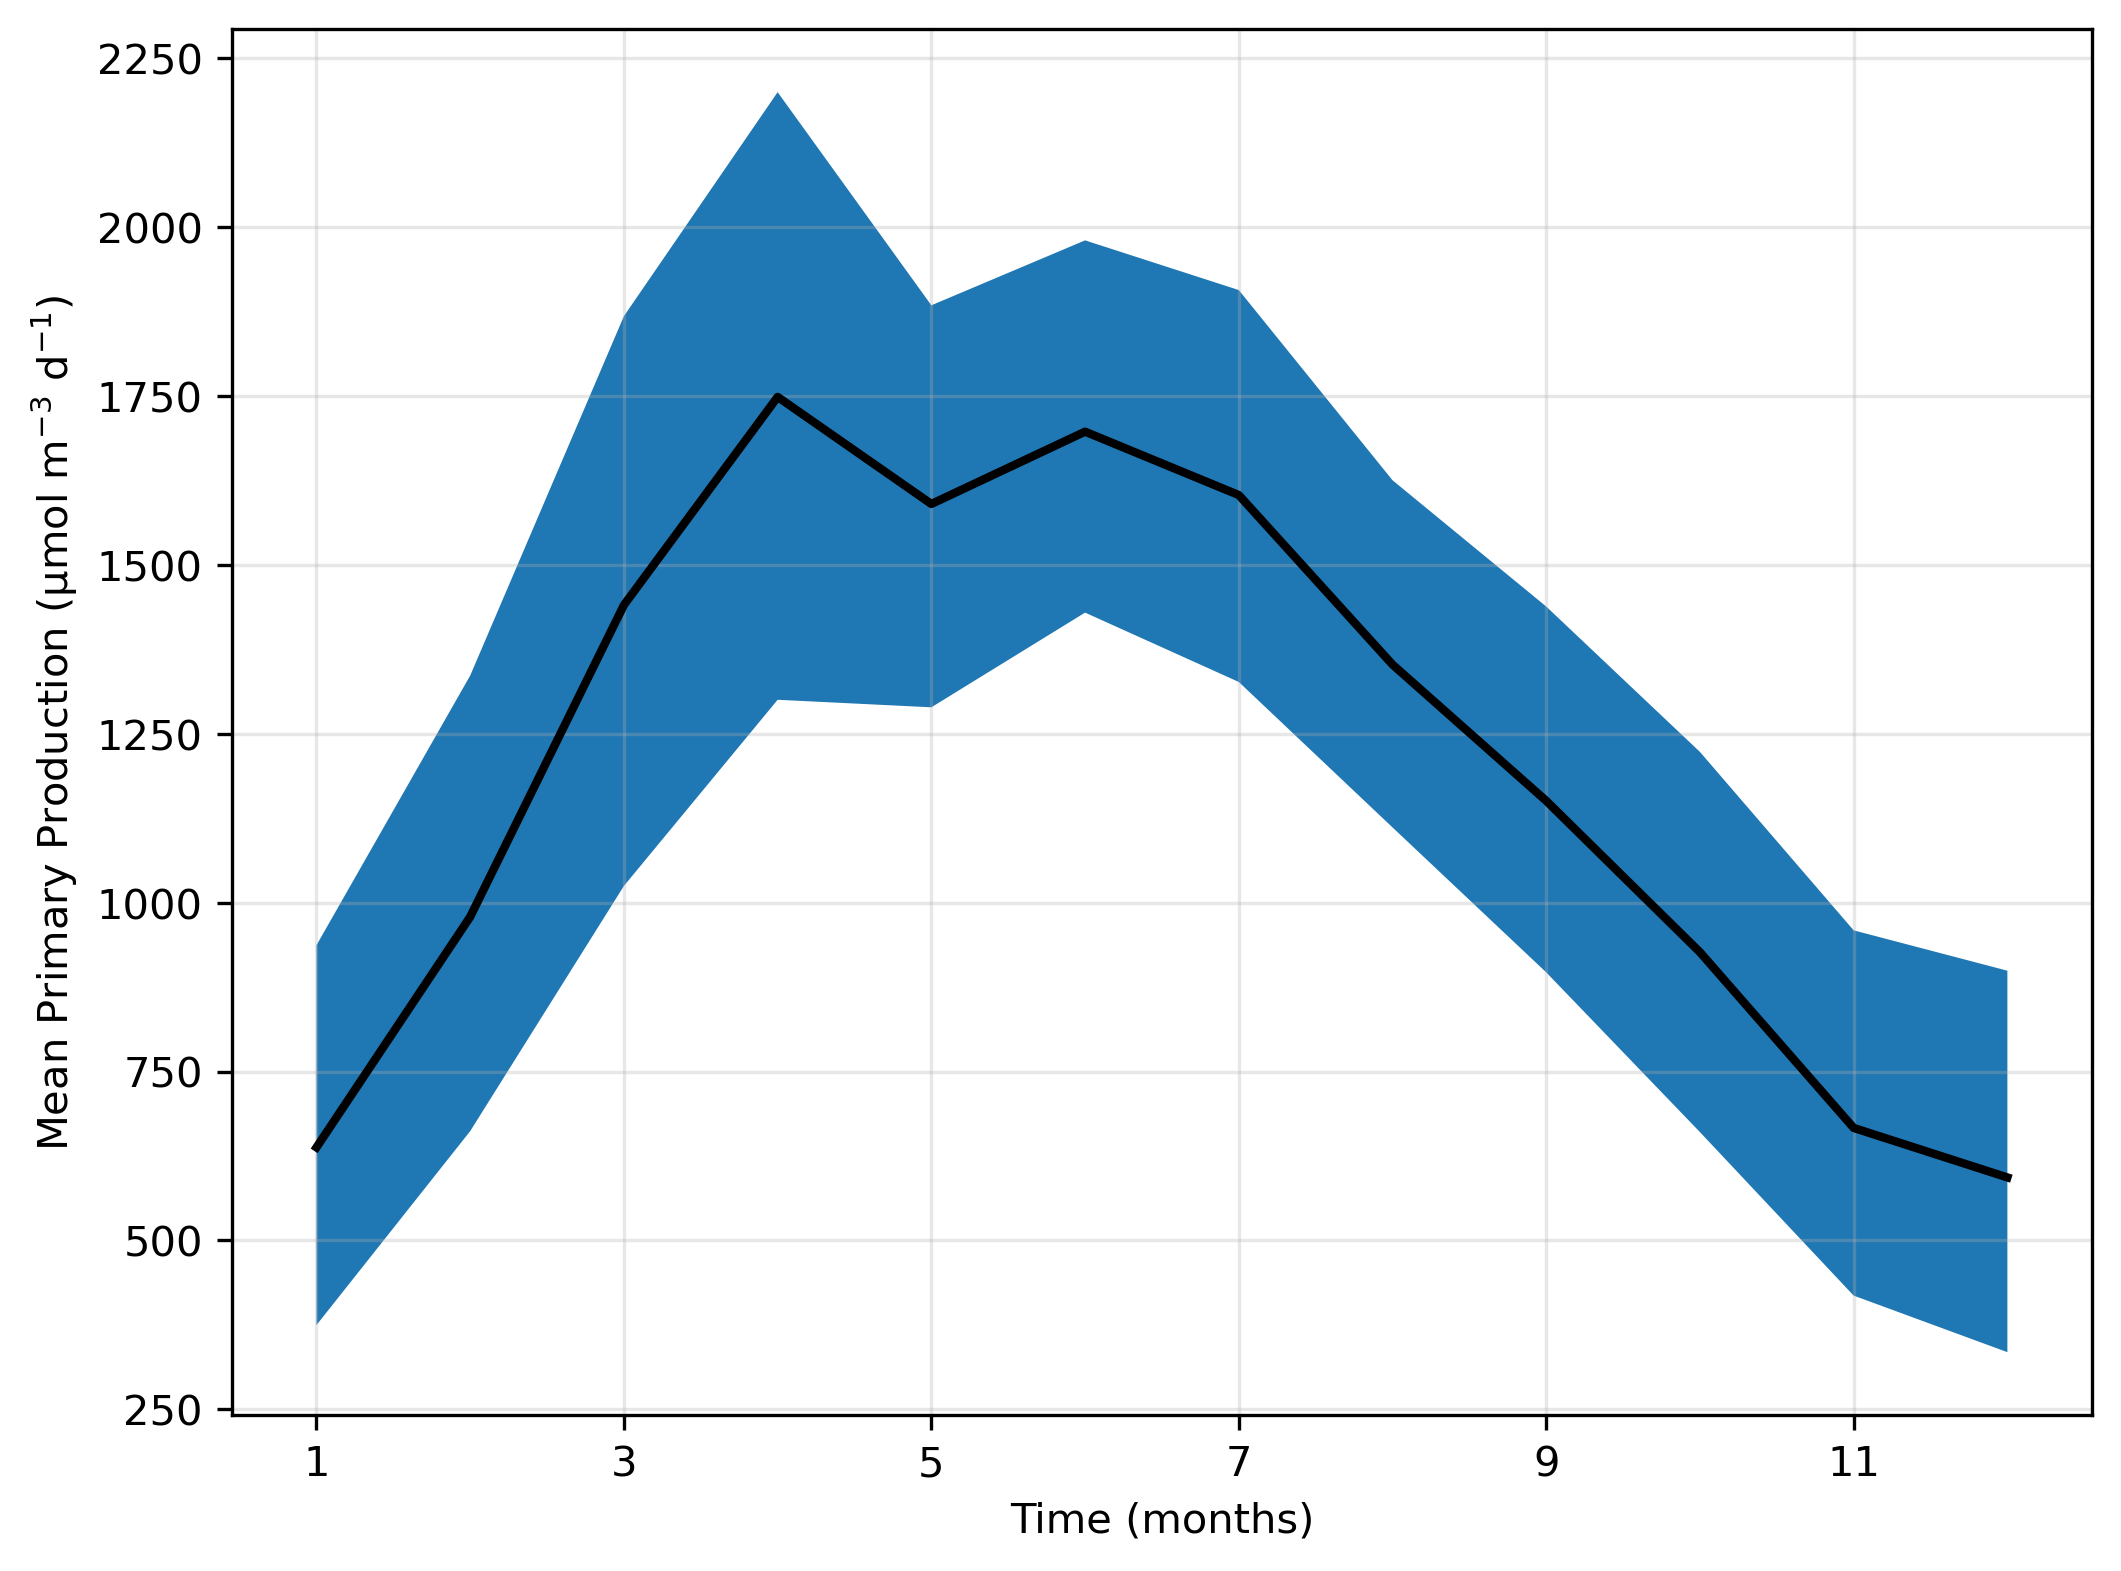

In [6]:
# Constants
R = 6.371e6             # Earth radius (m)
dlat = np.deg2rad(1.0)
dlon = np.deg2rad(1.0)
dz = 5.0                # m
molar_mass_C = 12.011   # g/mol
umol_to_mol = 1e-6
g_to_Tg = 1e-12
days_in_month = 30.44
conv_factor = molar_mass_C * umol_to_mol * g_to_Tg * days_in_month  # 12.011e-18

# Grid-cell area (broadcast to 2D lat/lon)
lat = np.deg2rad(ds_mean['lat'])
area = (R**2 * dlat * dlon * np.cos(lat)).broadcast_like(ds_mean[varname].isel(time=0, depth=0))

try:
    time_values = ds_mean['time'].values
except:
    time_values = np.arange(ds_mean[varname].shape[0])

mean_filled = xr.where(
    ds_mean[varname].isnull() & ds_mean[varname].notnull().any(dim='time'),
    0,
    ds_mean[varname]
)
LL_filled = xr.where(
    ds_LL[varname].isnull() & ds_LL[varname].notnull().any(dim='time'),
    0,
    ds_LL[varname]
)
UL_filled = xr.where(
    ds_UL[varname].isnull() & ds_UL[varname].notnull().any(dim='time'),
    0,
    ds_UL[varname]
)

# Keep time dimension even if biome is empty
mean_vals = mean_filled.mean(dim=['lat','lon','depth'], skipna=True, keepdims=False)
LL_vals   = LL_filled.mean(dim=['lat','lon','depth'], skipna=True, keepdims=False)
UL_vals   = UL_filled.mean(dim=['lat','lon','depth'], skipna=True, keepdims=False)

# Convert to numpy, ensuring it matches time_values length
mean_vals = mean_vals.reindex(time=time_values, fill_value=np.nan).values
LL_vals   = LL_vals.reindex(time=time_values, fill_value=np.nan).values
UL_vals   = UL_vals.reindex(time=time_values, fill_value=np.nan).values

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
ax.plot(time_values, mean_vals, color="black", linewidth=2)
ax.fill_between(time_values, LL_vals, UL_vals, alpha=1)
ax.set_ylabel(r'Mean Primary Production (µmol m$^{-3}$ d$^{-1}$)')

ax.grid(True, alpha=0.3)
ax.ticklabel_format(axis='y', style='plain', useOffset=False)
ax.set_xticks(np.arange(1, 13, 2))
ax.set_xlabel('Time (months)')